In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("data_cleaned.csv")
# data inspection and cleaning
df.isnull().sum()
#df.duplicated().sum()
df.head(30)

#data inspection completed

,ResponseId,MainBranch,CodingActivities,EdLevel,LearnCode,YearsCode,DevType,Country,LanguageHaveWorkedWith,LanguageWantToWorkWith,...,PlatformHaveWorkedWith,WebframeHaveWorkedWith,WebframeWantToWorkWith,MiscTechHaveWorkedWith,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,OpSysProfessional use,AISearchHaveWorkedWith
0,1,None of these,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,18,"Senior Executive (C-Suite, VP, etc.)",United States of America,HTML/CSS;JavaScript;Python,Bash/Shell (all shells);C#;Dart;Elixir;GDScrip...,...,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Deno;Elm;Nuxt.js;React;Svelte;Vue.js,Electron;React Native;Tauri,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Godot;npm;pnpm;Unity 3D;Unreal Engine;Vite;Web...,Vim;Visual Studio Code,Vim;Visual Studio Code,MacOS;Windows;Windows Subsystem for Linux (WSL),ChatGPT
2,3,I am a developer by profession,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,27,"Developer, back-end",United States of America,Bash/Shell (all shells);Go,Haskell;OCaml;Rust,...,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,NaN,NaN,Cargo;Docker;Kubernetes;Make;Nix,Cargo;Kubernetes;Nix,Emacs;Helix,Emacs;Helix,MacOS;Other Linux-based,NaN
3,4,I am a developer by profession,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,12,"Developer, front-end",United States of America,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,...,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Node.js;Ruby on Rails;Vue.js,NaN,Homebrew;npm;Vite;Webpack;Yarn,Homebrew;npm;Vite,IntelliJ IDEA;Vim;Visual Studio Code;WebStorm,IntelliJ IDEA;Vim;WebStorm,iOS;iPadOS;MacOS,NaN
4,5,I am a developer by profession,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,6,"Developer, full-stack",Philippines,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;Python;Rust;TypeScript,...,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Express;NestJS;Next.js;Node.js;React;Remix;Vue.js,NaN,Docker;npm;Webpack;Yarn,Docker;npm;Yarn,Vim;Visual Studio Code,Vim;Visual Studio Code,Other (Please Specify):,ChatGPT
5,6,I am a developer by profession,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,21,"Developer, back-end",United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,Go;Rust,...,Amazon Web Services (AWS);Cloudflare;Google Cloud,Angular;Express;NestJS;Node.js,NaN,NaN,Docker;Homebrew;Kubernetes;npm;pnpm;Terraform,Cargo,Helix;Neovim,NaN,MacOS,ChatGPT;Google Bard AI;Neeva AI
6,7,I am a developer by profession,Hobby;Contribute to open-source projects;Profe...,Some college/university study without earning ...,Friend or family member;Online Courses or Cert...,4,"Developer, full-stack",United States of America,Ada;Clojure;Elixir;Go;HTML/CSS;Java;JavaScript...,NaN,...,Amazon Web Services (AWS);Digital Ocean,AngularJS;jQuery;Node.js;Phoenix;Ruby on Rails...,NaN,RabbitMQ;Spring Framework,Bun;Cargo;Chocolatey;Docker;Homebrew;Kubernete...,NaN,Emacs;IntelliJ IDEA;RubyMine;Visual Studio Cod...,NaN,MacOS,ChatGPT
7,8,I am a developer by profession,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,5,"Developer, full-stack",United States of America,Go;HTML/CSS;JavaScript;Python;Rust;SQL;TypeScript,Elixir;Go;Julia;Python;R;Rust;S

In [3]:
df["MainBranch"]=df["MainBranch"].str.replace( "I am not primarily a developer, but I write code sometimes as part of my work/studies","casualcoder")
df["CodingActivities"]=df["CodingActivities"].str.replace( "Hobby","no real hooby")
India = df.query('Country == "India"')

Indian_Education = (
    India.groupby("EdLevel")["DevType"]
         .count()
         .sort_values(ascending=False)
)

Developer_Count = (
    India.dropna(subset=["DevType"])
         .groupby("DevType")["EdLevel"]
         .count()
         .sort_values(ascending=False)
)
# by this we can find out relation between indian devtype vs thier educational level 

In [2]:

df = df.drop(df.index[0])
df['YearsCode'] = df['YearsCode'].replace({
    'Less than 1 year': 0, # set to zero because expierences would be preety much useless for calculation if it was in months
    'More than 50 years': 51 # we do not know exact years how much dev has spent hence set to 51  
})
df['YearsCode'] = pd.to_numeric(df['YearsCode'], errors='coerce')
mean_value1 = df['YearsCode'].mean()
df['YearsCode'] = df['YearsCode'].fillna(mean_value1) # first category cleaned
df.isnull().sum() # check for nulls
cols_to_fill = [
    "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith",
    "PlatformHaveWorkedWith", "OpSysProfessional use",
    "WebframeHaveWorkedWith", "WebframeWantToWorkWith",
    "LanguageHaveWorkedWith", "LanguageWantToWorkWith",
    "ToolsTechHaveWorkedWith", "ToolsTechWantToWorkWith",
    "NEWCollabToolsHaveWorkedWith", "NEWCollabToolsWantToWorkWith",
    "AISearchHaveWorkedWith", "MiscTechHaveWorkedWith","CodingActivities","EdLevel","LearnCode","DevType","Country"          
]
df[cols_to_fill] = df[cols_to_fill].fillna("Unknown")
df.isnull().sum()
# null values cleaned

ResponseId                      0
MainBranch                      0
CodingActivities                0
EdLevel                         0
LearnCode                       0
YearsCode                       0
DevType                         0
Country                         0
LanguageHaveWorkedWith          0
LanguageWantToWorkWith          0
DatabaseHaveWorkedWith          0
DatabaseWantToWorkWith          0
PlatformHaveWorkedWith          0
WebframeHaveWorkedWith          0
WebframeWantToWorkWith          0
MiscTechHaveWorkedWith          0
ToolsTechHaveWorkedWith         0
ToolsTechWantToWorkWith         0
NEWCollabToolsHaveWorkedWith    0
NEWCollabToolsWantToWorkWith    0
OpSysProfessional use           0
AISearchHaveWorkedWith          0
dtype: int64

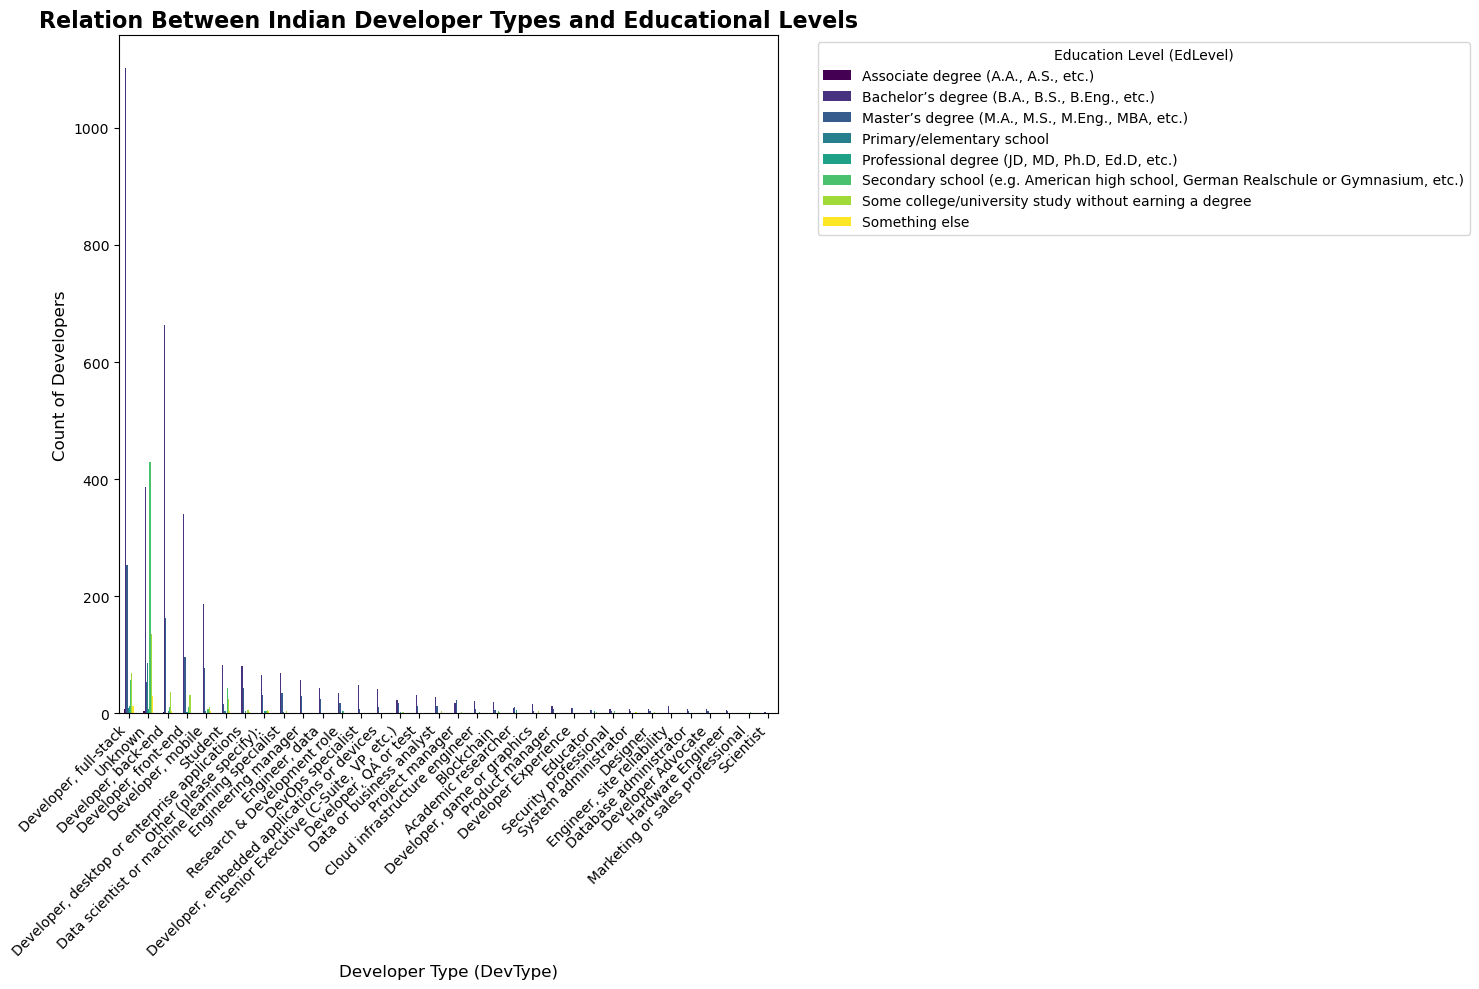

In [16]:
dev_ed_relation = pd.crosstab(India["DevType"], India["EdLevel"])
dev_ed_relation["Total"] = dev_ed_relation.sum(axis=1)
dev_ed_relation = dev_ed_relation.sort_values(by="Total", ascending=False).drop(
    columns="Total"
)

fig, ax = plt.subplots(figsize=(15, 10))
dev_ed_relation.plot(kind="bar", stacked=False, cmap="viridis", ax=ax)

plt.title(
    "Relation Between Indian Developer Types and Educational Levels",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Developer Type (DevType)", fontsize=12)
plt.ylabel("Count of Developers", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Education Level (EdLevel)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


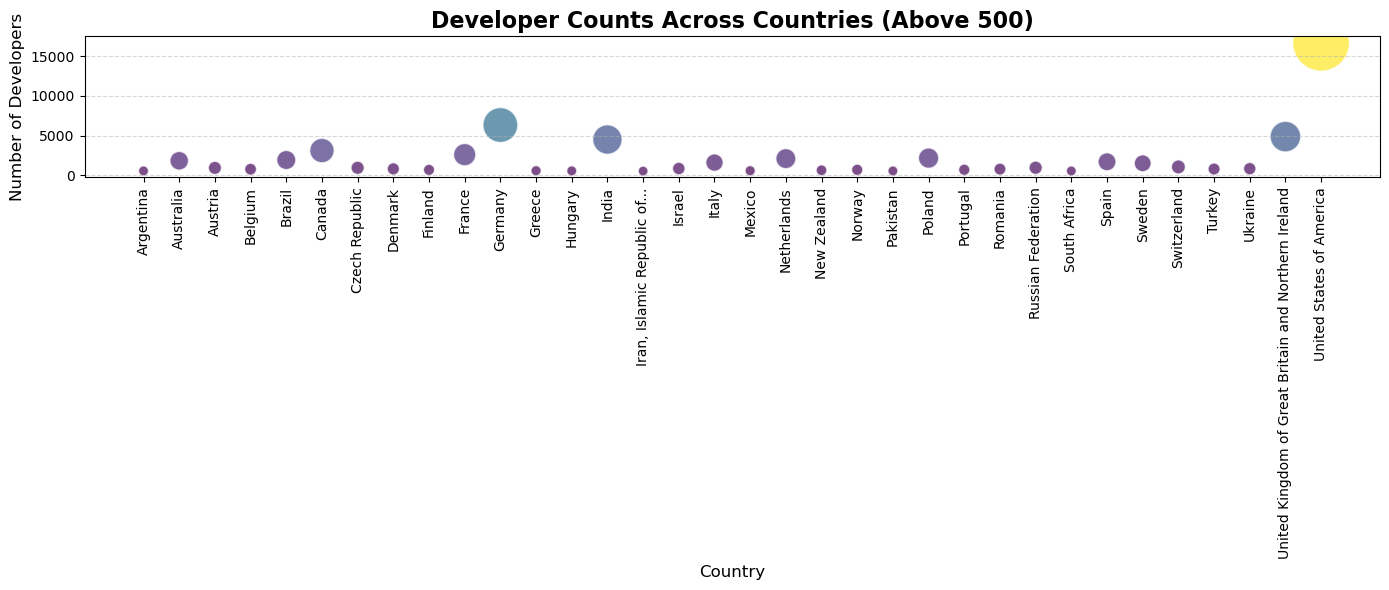

In [57]:
#Developer Counts Across Countries (Above 500) 
county = df.query('DevType != "Unknown"')
countries = county.groupby("Country")["DevType"].count()
countries = countries[countries > 500].reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(
    x=countries["Country"],
    y=countries["DevType"],
    s=countries["DevType"] * 0.1,
    c=countries["DevType"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="w",
)

plt.title(
    "Developer Counts Across Countries (Above 500)", fontsize=16, fontweight="bold"
)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Developers", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
